# MALL CUSTOMER SEGMENTATION

## Content
* You are owing a supermarket mall and through membership cards , you have some basic data about your customers like Customer ID, age, gender, annual income and spending score.
Spending Score is something you assign to the customer based on your defined parameters like customer behavior and purchasing data.

## Problem Statement
* You own the mall and want to understand the customers like who can be easily converge [Target Customers] so that the sense can be given to marketing team and plan the strategy accordingly.

In [19]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# reading the dataset 
mall_df = pd.read_csv('./Mall_Customers.csv')
mall_df.sample(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
182,183,Male,46,98,15
172,173,Male,36,87,10
124,125,Female,23,70,29
10,11,Male,67,19,14
195,196,Female,35,120,79


In [21]:
# analyzing the dataset
mall_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              250 non-null    int64 
 1   Gender                  250 non-null    object
 2   Age                     250 non-null    int64 
 3   Annual Income (k$)      250 non-null    int64 
 4   Spending Score (1-100)  250 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 9.9+ KB


In [22]:
round(mall_df.describe().T,2)

,count,mean,std,min,25%,50%,75%,max
CustomerID,250.0,125.50,72.31,1.0,63.25,125.5,187.75,250.0
Age,250.0,38.49,13.17,18.0,29.00,36.0,47.75,70.0
Annual Income (k$),250.0,95.59,77.31,15.0,47.00,70.0,101.00,325.0
Spending Score (1-100),250.0,50.24,27.29,1.0,27.00,50.0,74.00,99.0


In [23]:
# checking for null values
mall_df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

* observation : this dataset does not have any null values

# visualization


<Axes: xlabel='Age', ylabel='Annual Income (k$)'>

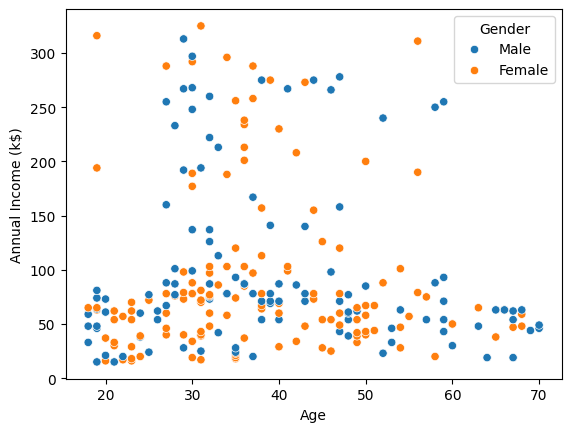

In [24]:
sns.scatterplot(data = mall_df, x = 'Age', y = 'Annual Income (k$)', hue = 'Gender')

<Axes: xlabel='Age', ylabel='Spending Score (1-100)'>

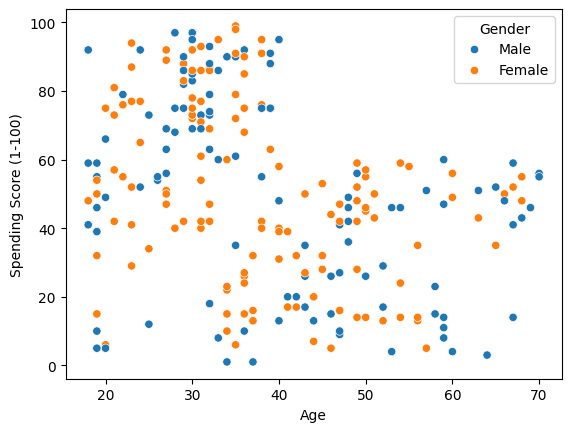

In [25]:
sns.scatterplot(data = mall_df, x = 'Age', y = 'Spending Score (1-100)', hue = 'Gender')


<Axes: xlabel='Gender', ylabel='Spending Score (1-100)'>

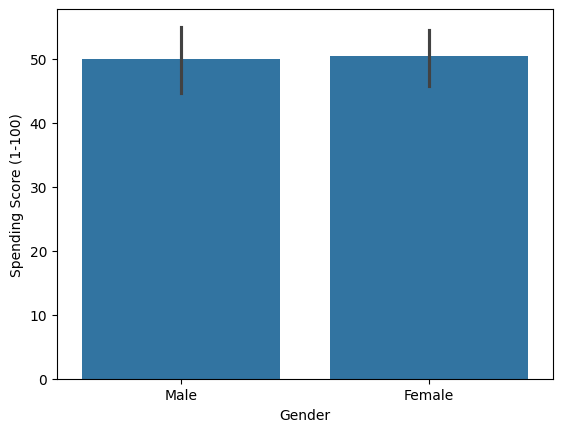

In [26]:
sns.barplot(data = mall_df, x = 'Gender', y = 'Spending Score (1-100)')

# checking the unique values

In [27]:
categorical_cols = mall_df.select_dtypes(include = 'object').columns.tolist()
numerical_cols = mall_df.select_dtypes(include = np.number).columns.tolist()

In [28]:
for cols in categorical_cols:
    unique_val = mall_df[cols].value_counts()
    print(f'Cols : {cols}')
    print(f'Unique : {unique_val}')

Cols : Gender
Unique : Gender
Female    137
Male      113
Name: count, dtype: int64


In [29]:
for cols in numerical_cols:
    unique_val = mall_df[cols].value_counts()
    print(f'Cols : {cols}')
    print(f'Unique : {unique_val}')

Cols : CustomerID
Unique : CustomerID
1      1
2      1
3      1
4      1
5      1
      ..
246    1
247    1
248    1
249    1
250    1
Name: count, Length: 250, dtype: int64
Cols : Age
Unique : Age
30    13
32    13
31    10
35    10
19    10
36    10
27     9
47     8
29     8
38     8
34     7
40     7
49     7
37     6
23     6
50     6
20     5
43     5
21     5
48     5
59     5
28     5
39     5
44     4
67     4
24     4
54     4
46     4
33     4
18     4
45     3
58     3
22     3
52     3
25     3
42     3
41     3
56     3
68     3
60     3
57     2
53     2
65     2
66     2
51     2
63     2
70     2
26     2
64     1
69     1
55     1
Name: count, dtype: int64
Cols : Annual Income (k$)
Unique : Annual Income (k$)
54     12
78     12
48      6
62      6
60      6
       ..
297     1
311     1
313     1
316     1
325     1
Name: count, Length: 107, dtype: int64
Cols : Spending Score (1-100)
Unique : Spending Score (1-100)
75    9
42    8
13    7
55    7
46    6
     ..
71

* observation : we do not need to scale the gender column because it can distort the model, we only need two columns Annual Income and spending score 

In [32]:
# dropping the customer Id column
mall_df.drop('CustomerID',inplace=True,axis=1)

# TRAINING THE MODEL

In [33]:
X = mall_df[['Annual Income (k$)','Spending Score (1-100)']]

# scaling 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# FINDING THE OPTIMAL k WITH ELBOW METHOD

In [34]:
from sklearn.cluster import KMeans

Text(0, 0.5, 'Intertia')

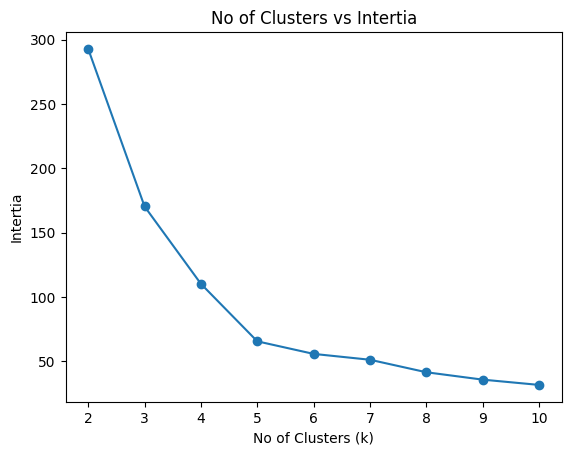

In [35]:
options = range(2,11)
intertias = []

for k in options :
    model = KMeans(n_clusters=k,random_state=42).fit(X_scaled)
    intertias.append(model.inertia_)

plt.title("No of Clusters vs Intertia")
plt.plot(options,intertias,'-o')
plt.xlabel('No of Clusters (k)')
plt.ylabel('Intertia')

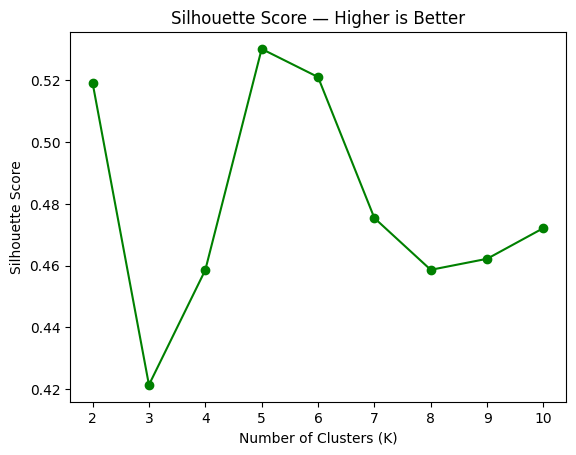

In [40]:
from sklearn.metrics import silhouette_score

silhouettes = []
for k in options:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    silhouettes.append(silhouette_score(X_scaled, labels))

plt.plot(options, silhouettes, marker='o', color='green')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Higher is Better')
plt.show()

In [36]:
# training the model

model = KMeans(n_clusters=5, random_state=42)
model.fit(X_scaled)
mall_df['Clusters'] = model.predict(X_scaled)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

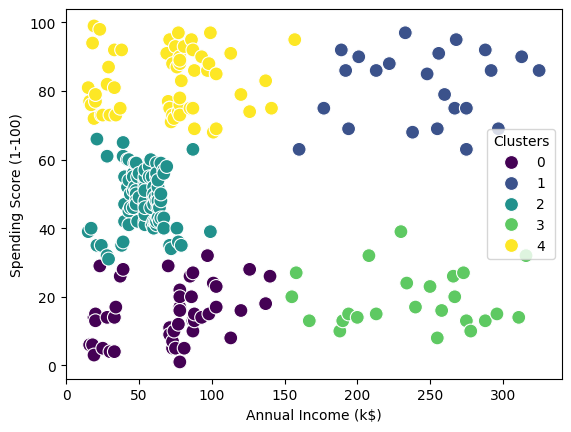

In [38]:
sns.scatterplot(
    data=mall_df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Clusters',
    palette='viridis',
    s=100
)

In [42]:
mall_df.groupby('Clusters')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

# Expected 5 segments:
# Cluster 0 → "Careful"        — high income, low spending
# Cluster 1 → "Standard"       — medium income, medium spending
# Cluster 2 → "Target"         — high income, high spending ← most valuable!
# Cluster 3 → "Spendthrift"    — low income, high spending
# Cluster 4 → "Sensible"       — low income, low spending

,Age,Annual Income (k$),Spending Score (1-100)
Clusters,,,
0,42.895833,70.125000,14.854167
1,31.260870,245.130435,81.260870
2,42.020833,53.333333,48.531250
3,42.250000,237.916667,19.000000
4,30.457627,68.881356,82.440678


In [44]:
# TRYING THE DBSCAN - DENSITY BASED CLUSTERING

from sklearn.cluster import DBSCAN

model = DBSCAN(eps = 0.5 , min_samples = 5)
mall_df['Dbscan_Cluster'] = model.fit_predict(X_scaled)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

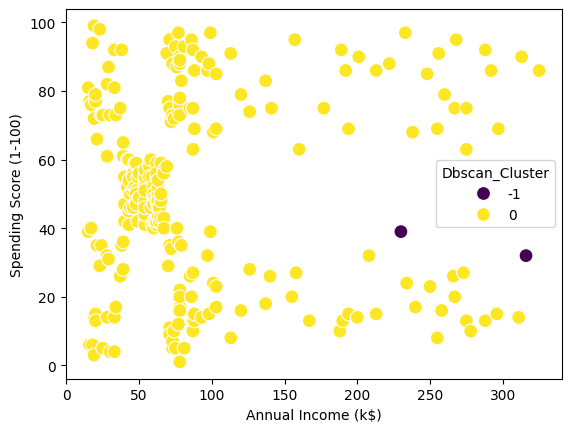

In [45]:
sns.scatterplot(
    data=mall_df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Dbscan_Cluster',
    palette='viridis',
    s=100
)